# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Tangaran, Grisby Paul James 
- _Student No._: 2024-02777
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

### Problem 1: Root Finding
![Plot of the given function](7-function.png)

Figure 1. Plot of the given function

A.
![Plots of the convergence of the values of the root 1](7-root1.png)

B.
![Plots of the convergence of the values of the root 2](7-root2.png)

C.
![Plots of the convergence of the values of the root 3](7-root3.png)

Figure 2. Plots of the convergence of the values of the roots (A. Root 1, B. Root 2, C. Root 3)

### Report discussion

The convergence plots track the root estimate $x_i$ against the iteration step $i$ for each root. Newton's method is the fastest to reach the target root for simple roots (Roots 1 and 3), followed by the Fixed-Point and Bisection methods, while the Secant method is the slowest due to its initial path. For Root 2 ($x = 2.0$), Bisection fails completely because the function touches zero without changing sign, returning no result.  Additionally, the Secant method displays noticeable initial oscillations before settling on Root 2 and Root 3.

These convergence patterns highlight the practical trade-offs between each root-finding algorithm. Newton's method offers rapid convergence but requires an analytical derivative $f'(x)$ and can struggle near flat slopes. The Secant method avoids explicit derivatives, but its reliance on numerical slope approximations makes it prone to heavy overshooting and instability when starting far from a root. Fixed-Point iteration provides smooth, steady progress, though its success depends entirely on designing a suitable transformation function $g(x)$. Finally, while the Bisection method is reliable for sign-changing brackets, its progress is relatively slow, and it cannot find roots of even multiplicity where no sign change occurs.

### Other comments
-  None


---
## Section 2: Code

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

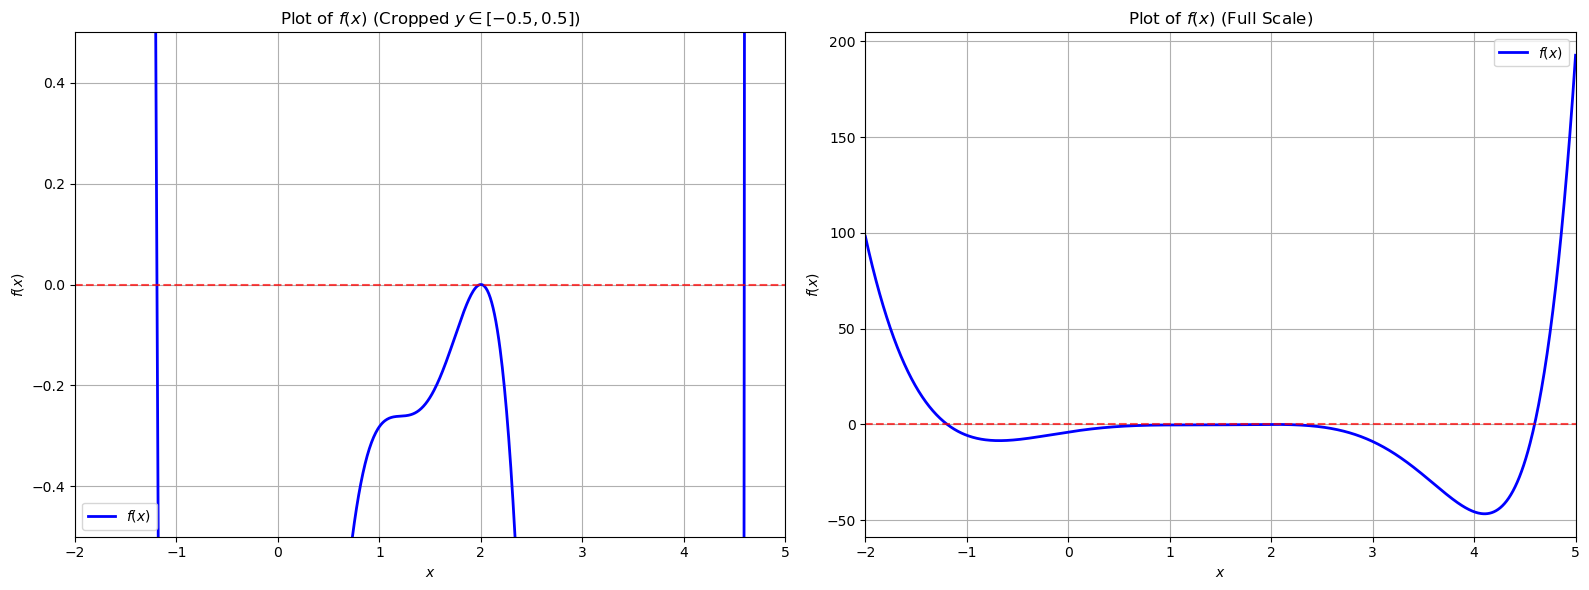

Root 1:
Fixed-Point (g1, xold = -1.5)    : x = -1.1926857629960477
Bisection   (x0 = -2, x1 = 0)    : x = -1.1926857605576515
Secant      (x0 = -2, x1 = -1.5) : x = -1.1926857650225988
Newton      (x0 = -1.5)          : x = -1.1926857650226048

Root 2:
Fixed-Point (g2, xold=1.8)       : x = 1.9999999476177657
Bisection   (f, x0=1.5, x1=2.5)  : x = None
Secant      (x0 = 1.9, x1 = 2.1) : x = 2.0000000393171709
Newton      (x0 = 1.8)           : x = 1.9999685443558120

Root 3:
Fixed-Point (g3, xold = 4.5)     : x = 4.5958635547546649
Bisection   (x0 = 4.0, x1= 5.0)  : x = 4.5958635509014130
Secant      (x0 = 4.0, x1= 5.0)  : x = 4.5958635649223725
Newton      (x0 = 4.5)           : x = 4.5958635649237367



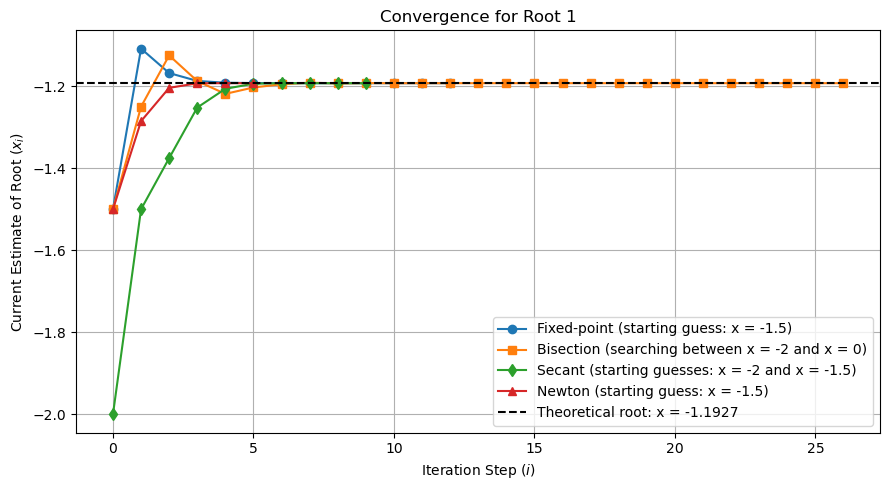

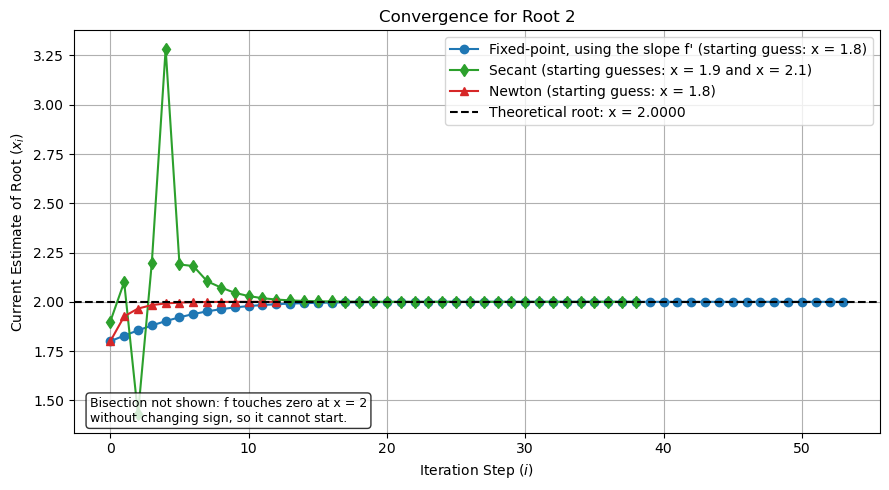

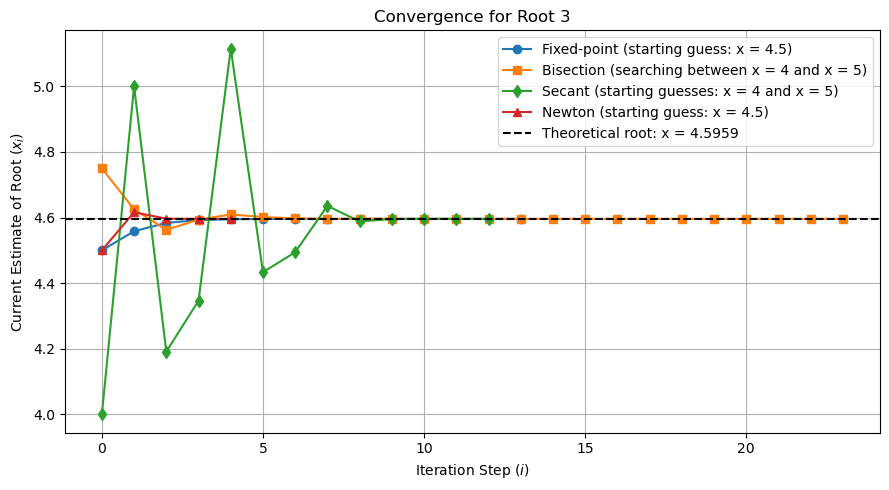

In [34]:

def f(x):
    #function
    return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

def df(x):
    #Derivative of the function: -5x^4 +16x^3 -12x^2 -4x + 8 + (x^2 - 2x)e^x
    return -5*x**4 + 16*x**3 - 12*x**2 - 4*x + 8 + (x**2 - 2*x)*np.exp(x)

# 1. Fixed-Point Method as in the book
def fixedpoint(f,xold,kmax=200,tol=1.e-8):
    history = [xold] # Track iteration progress starting from x0
    for k in range(1,kmax):
        xnew = f(xold) # Apply fixed-point update transformation
        xdiff = xnew - xold
        history.append(xnew) # Record current iteration estimate
        if abs(xdiff/xnew) < tol: # Relative change stopping criterion
            break
        xold = xnew
    else:
        xnew = None # Flag non-convergence if max iterations exceeded
    return xnew, history

# 2. Bisection Bracketing Method
def bisection(f, x0, x1, kmax=200, tol=1e-8):
    f0, f1 = f(x0), f(x1)
    if f0*f1 > 0: # Ensure interval brackets a sign change
        return None, []
    history = []
    for k in range(1, kmax):
        x2 = (x0 + x1)/2  # Calculate midpoint of current interval
        f2 = f(x2)
        if f2 == 0:  # Check for exact root landing
            history.append(x2)
            return x2, history
        if f0*f2 < 0:  # Narrow down to left sub-interval
            x1, f1 = x2, f2
        else:  # Narrow down to right sub-interval
            x0, f0 = x2, f2
        x2new = (x0 + x1)/2      # Compute updated midpoint estimate
        history.append(x2new)    # Record current midpoint estimate
        if abs(x2new - x2)/abs(x2new) < tol: # Check relative interval tolerance
            break
    else:
        x2new = None   # Non-convergence 
    return x2new, history
    
# 3. Secant Method 
def secant(f, x0, x1, kmax=200, tol=1.e-8):
    f0 = f(x0)
    history = [x0, x1]     # Initialize history with initial two points
    for k in range(1, kmax):
        f1 = f(x1)
        if abs(f1 - f0) < 1e-14:  # Prevent division by zero from flat slope
            break
        ratio = (x1 - x0)/(f1 - f0) # Compute inverse finite difference ratio
        x2 = x1 - f1*ratio  # Calculate secant root estimate
        xdiff = abs(x2-x1)
        x0, x1 = x1, x2
        f0 = f1

        history.append(x2)  # Record current estimate
        if abs(xdiff/x2) < tol:  # Relative step convergence check
            break
    else:
        x2 = None  # Non-convergence 
    return x2, history   
    
# 4. Newton-Raphson Method
def newton(f, df, x0, kmax=200, tol=1.e-8):
    xold = x0
    history = [xold]    # Log initial guess
    for k in range(kmax):
        fx = f(xold)
        if abs(fx) < tol:  # Stopping condition based on residual error |f(x)|
            return xold, history
        dfx = df(xold)
        if abs(dfx) < 1e-14:  # Guard against zero/near-zero derivative
            return None, history
        xnew = xold - fx / dfx  # Newton-Raphson step: x_{n+1} = x_n - f(x_n)/f'(x_n)
        history.append(xnew)  # Record updated estimate
        xold = xnew
    return None, history

x_values = np.linspace(-2, 5, 1000)
y_values = f(x_values)

# Side-by-side plots of f(x)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# First plot: Cropped
ax1.plot(x_values, y_values, color='blue', linewidth=2, label=r'$f(x)$')
ax1.axhline(0, color='red', linestyle='--', alpha=0.7)
ax1.set_ylim(-0.5, 0.5)
ax1.set_xlim(-2, 5)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$f (x)$')
ax1.set_title('Plot of $f(x)$ (Cropped $y \in [-0.5, 0.5]$)')
ax1.grid(True)
ax1.legend()

# Second plot: Full scale
ax2.plot(x_values, y_values, color='blue', linewidth=2, label=r'$f(x)$')
ax2.axhline(0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlim(-2, 5)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$f (x)$')
ax2.set_title('Plot of $f(x)$ (Full Scale)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig("7-function.png")
plt.show()

#Relaxation transformation functions g(x) for fixed-point iteration
g1 = lambda x: x + 0.02 * f(x)
g2 = lambda x: x + 0.05 * df(x)
g3 = lambda x: x - 0.003 * f(x)

# Evaluate Root 1 using all four methods
root1_fp, hist1_fp = fixedpoint(g1, xold=-1.5)
root1_bi, hist1_bi = bisection(f, x0=-2.0, x1=0.0)
root1_sc, hist1_sc = secant(f, x0=-2.0, x1=-1.5)
root1_nt, hist1_nt = newton(f, df, x0=-1.5)

print("Root 1:")
print(f"Fixed-Point (g1, xold = -1.5)    : x = {root1_fp:.16f}")
print(f"Bisection   (x0 = -2, x1 = 0)    : x = {root1_bi:.16f}")
print(f"Secant      (x0 = -2, x1 = -1.5) : x = {root1_sc:.16f}")
print(f"Newton      (x0 = -1.5)          : x = {root1_nt:.16f}\n")

# Evaluate Root 2 using applicable methods
root2_fp, hist2_fp = fixedpoint(g2, xold=1.8)
root2_bi, hist2_bi = bisection(f, x0=1.5, x1=2.5) # f'(x) changes sign at double root
root2_sc, hist2_sc = secant(f, x0=1.9, x1=2.1)
root2_nt, hist2_nt = newton(f, df, x0=1.8)

print("Root 2:")
print(f"Fixed-Point (g2, xold=1.8)       : x = {root2_fp:.16f}") # Added Fixed-Point print statement
print(f"Bisection   (f, x0=1.5, x1=2.5)  : x = {root2_bi}")
print(f"Secant      (x0 = 1.9, x1 = 2.1) : x = {root2_sc:.16f}")
print(f"Newton      (x0 = 1.8)           : x = {root2_nt:.16f}\n")


# Evaluate Root 3 using all four methods
root3_fp, hist3_fp = fixedpoint(g3, xold=4.5)
root3_bi, hist3_bi = bisection(f, x0=4.0, x1=5.0)
root3_sc, hist3_sc = secant(f, x0=4.0, x1=5.0)
root3_nt, hist3_nt = newton(f, df, x0=4.5)

print("Root 3:")
print(f"Fixed-Point (g3, xold = 4.5)     : x = {root3_fp:.16f}")
print(f"Bisection   (x0 = 4.0, x1= 5.0)  : x = {root3_bi:.16f}")
print(f"Secant      (x0 = 4.0, x1= 5.0)  : x = {root3_sc:.16f}")
print(f"Newton      (x0 = 4.5)           : x = {root3_nt:.16f}\n")

# Exact analytical baseline roots for error reference
true1 = -1.1926857650
true2 = 2.0
true3 = 4.5958635649

# 1. Plot for Root 1
plt.figure(figsize=(9, 5))
plt.plot(hist1_fp, marker='o', color='tab:blue', label="Fixed-point (starting guess: x = -1.5)")
plt.plot(hist1_bi, marker='s', color='tab:orange', label="Bisection (searching between x = -2 and x = 0)")
plt.plot(hist1_sc, marker='d', color='tab:green', label="Secant (starting guesses: x = -2 and x = -1.5)")
plt.plot(hist1_nt, marker='^', color='tab:red', label="Newton (starting guess: x = -1.5)")
plt.axhline(true1, color='black', linestyle='--', linewidth=1.5, label=f"Theoretical root: x = {true1:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Current Estimate of Root ($x_i$)')
plt.title('Convergence for Root 1')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("7-root1.png")
plt.show()

# 2. Plot for Root 2
plt.figure(figsize=(9, 5))
plt.plot(hist2_fp, marker='o', color='tab:blue', label="Fixed-point, using the slope f' (starting guess: x = 1.8)")
#plt.plot(hist2_bi, marker='s', color='tab:orange', label="Bisection (searching between x = 1.5 and x = 2.5)")
plt.plot(hist2_sc, marker='d', color='tab:green', label="Secant (starting guesses: x = 1.9 and x = 2.1)")
plt.plot(hist2_nt, marker='^', color='tab:red', label="Newton (starting guess: x = 1.8)")
plt.axhline(true2, color='black', linestyle='--', linewidth=1.5, label=f"Theoretical root: x = {true2:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Current Estimate of Root ($x_i$)')
plt.title('Convergence for Root 2')
plt.text(0.02, 0.02,
         "Bisection not shown: f touches zero at x = 2\nwithout changing sign, so it cannot start.",
         transform=plt.gca().transAxes, fontsize=9, va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("7-root2.png")
plt.show()

# 3. Plot for Root 3
plt.figure(figsize=(9, 5))
plt.plot(hist3_fp, marker='o', color='tab:blue', label="Fixed-point (starting guess: x = 4.5)")
plt.plot(hist3_bi, marker='s', color='tab:orange', label="Bisection (searching between x = 4 and x = 5)")
plt.plot(hist3_sc, marker='d', color='tab:green', label="Secant (starting guesses: x = 4 and x = 5)")
plt.plot(hist3_nt, marker='^', color='tab:red', label="Newton (starting guess: x = 4.5)")
plt.axhline(true3, color='black', linestyle='--', linewidth=1.5, label=f"Theoretical root: x = {true3:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Current Estimate of Root ($x_i$)')
plt.title('Convergence for Root 3')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("7-root3.png")
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
* This code evaluates and compares four fundamental root-finding algorithms (Fixed-Point Iteration, Bisection, Secant, and Newton-Raphson) to locate all three real roots of the non-linear function $f(x)$. The core functions were adapted directly from the Gezerlis textbook implementations but modified to collect and return an iteration history array alongside the final root estimate. This design choice allows step-by-step convergence tracking and enables direct visual plotting to compare each method across different initial guesses.

In [41]:
print("Fixed Point Root 1: ", hist1_fp, "\n")
print("Bisection Root 1: " , hist1_bi,"\n")
print("Secant Root 1: ", hist1_sc, "\n")
print("Newton Root 1: ", hist1_nt, "\n")


print("Fixed Point Root 2: ", hist2_fp, "\n")
print("Bisection Root 2: " , hist2_bi, "\n")
print("Secant Root 2: ", hist2_sc, "\n")
print("Newton Root 2: ", hist2_nt ,"\n")


print("Fixed Point Root 3: ", hist3_fp, "\n")
print("Bisection Root 3: " , hist3_bi, "\n")
print("Secant Root 3: ", hist3_sc, "\n")
print("Newton Root 3: ", hist3_nt, "\n")

Fixed Point Root 1:  [-1.5, -1.1084581107636347, -1.167977806820475, -1.1871832569239873, -1.1915918238736796, -1.1924743657695145, -1.1926451491863883, -1.1926779703446173, -1.1926842694521558, -1.1926854780783598, -1.1926857099691308, -1.1926857544599903, -1.1926857629960477] 

Bisection Root 1:  [-1.5, -1.25, -1.125, -1.1875, -1.21875, -1.203125, -1.1953125, -1.19140625, -1.193359375, -1.1923828125, -1.19287109375, -1.192626953125, -1.1927490234375, -1.19268798828125, -1.192657470703125, -1.1926727294921875, -1.1926803588867188, -1.1926841735839844, -1.1926860809326172, -1.1926851272583008, -1.192685604095459, -1.192685842514038, -1.1926857233047485, -1.1926857829093933, -1.192685753107071, -1.1926857680082321, -1.1926857605576515] 

Secant Root 1:  [-2.0, -1.5, -1.3754451876572122, -1.252120140320278, -1.206424354967191, -1.193879810700264, -1.1927111060565463, -1.1926858123906805, -1.1926857650244802, -1.1926857650225988] 

Newton Root 1:  [-1.5, -1.2852000730360373, -1.2040484135